# Watch Calibration Experiment

The watch calibration experiment serves as an extremely basic example of how to record data, analyze it, and make your experiment completely reproducible for others far into the future. The concept of and code for this experiment is rather simple, and the focus is instead on best practices for archiving data, code, and the environment that runs the code.

## jupyter notebook

This jupyter notebook serves as an electronic lab notebook tied to a reproducible development environment. It provides a walkthrough of the data collection process, some justification of methods, and a very basic analysis using mostly numpy, scipy, and matplotlib. Cells may be rerun by using the controls on the top bar or using Shift+Enter, or the contents may be examined statically.

## imports and setup

In [1]:
# automatically reload watch_calibration python package in case we edit it
%load_ext autoreload
%autoreload 2
# enable the ipympl backend for interactive figures
%matplotlib widget

import base64
import copy
import os
import time 

import librosa
import matplotlib
import numpy as np
import random
import scipy
from IPython.display import HTML, display
from matplotlib import pyplot as plt
from scipy import signal as sps
from scipy.io.wavfile import write

# import watch calibration experiment code
from watch_calibration import WatchCalibration, plot_wins, plot_peaks, generate_figures

In [2]:
# set environment variables
RAW_DATA_PATH = os.environ["ARTS_RAW_DATA_PATH"]

In [3]:
# prevent race condition where plots aren't showing after "Restart Kernel and Run All Cells" is selected
time.sleep(.5)

# suppress warning about too many open figures
plt.rcParams.update({'figure.max_open_warning': 0})

In [4]:
# close all open plots to free up memory
plt.close('all')

## raw data collection/generation

### Generate new dataset

In [5]:
# show all system audio inputs and outputs
WatchCalibration.query_devices()

In [6]:
%%sh

# Datasets recording using the collect_data script will also run trusted timestamping 

# Generate 60s dataset using librosa
# ../scripts/collect_data.sh -g -d 60
# or with a signal-to-noise ratio of -15 dB
# ../scripts/collect_data.sh -g -d 60 -s -15 -x _noisy

# Record 60s dataset from microphone at 44.1 kHz using the default input device
# ../scripts/collect_data.sh -d 60 -r 44100
# or a specific input device as 
# ../scripts/collect_data.sh -d 60 -r 44100

### Load existing datasets

In [7]:
# audio recording parameters

# use system defaults; can change to int values above corresponding to specific interfaces
INPUT_DEVICE = None
OUTPUT_DEVICE = None

DATA_NAMES = [
    "W241130",
    "250227",
    "250409",
    "250410_noisy"
]
DEFAULT_DATA_NAME = DATA_NAMES[0]

In [8]:
# instantiate experiment code class for each watch calibration recording
wcs = {}
for name in DATA_NAMES: 
    wcs[name] =  WatchCalibration(name)
wc = wcs[DEFAULT_DATA_NAME]

### Create test data

In [9]:
# Uncomment the next lines to record duration seconds of audio to file and load it to memory
# wc.save_audio_to_file(duration=5*60, generate=False, input_device=INPUT_DEVICE÷)
# test_audio = wc.load_audio()

# Uncomment the next line to generate 60 seconds of audio without writing to file
# test_audio = wc.generate_audio(2)

# play audio file
# Uncomment the next line to play the selected audio file
# wc.play_audio(test_audio, wc.fs, output_device=OUTPUT_DEVICE)

### Listen to created data

In [10]:
# play audio file
# Uncomment the next line to play the selected audio file
# wc.play_audio(audio_file, output_device=OUTPUT_DEVICE)

## data visualization

In [11]:
watch_audio, fs = wc.load_audio()

### plot time and frequency signal

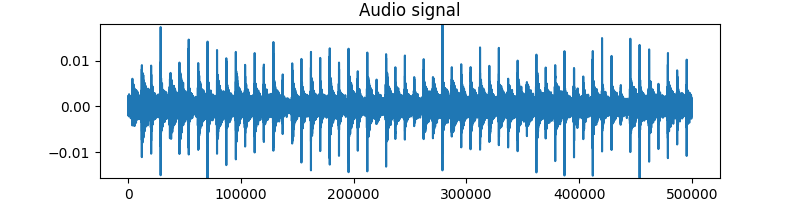

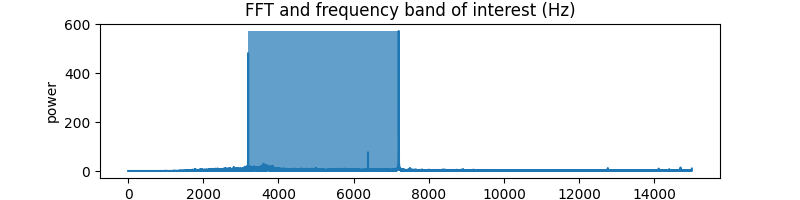

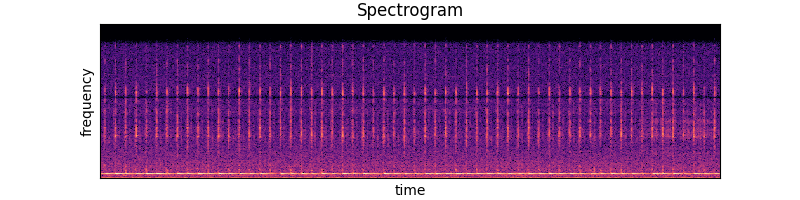

In [12]:
PLT_SECS = 10 

# plot last PLT_SECS seconds of time signal and spectrogram; plot full fft 
wc.plot_audio(watch_audio, plt_secs=PLT_SECS)

## derivative data

In [16]:
deriv_data = wc.create_deriv_from_raw(filter=False)
wc.save_deriv_data()

In [1]:
%%sh

# timestamp derivative data
../scripts/timestamp.sh W241130 ../deriv_data/W241130 ../deriv_data

/usr/src/exp/tts /usr/src/exp/notebooks


Cloning into 'timestamping'...


Hashing data directory and generating timestamp request...
Timestamp request generated

reply...timestamp request to timestamp authority servers and receiving 
Timestamp replies received

Verifying timestamp replies...
Verifying Apple: OK 
Verifying DigiCert: OK 
Verifying GlobalSign: OK 
Verifying IdenTrust: OK 
Verifying Microsoft: FAILED 
/ess_lib.c:280:FFFF0000:error:1B000068:ESS routines:find:ess cert id not found:../crypto/ess
Verifying Sectigo: OK 
Verification complete

Building timestamps JSON...
Timestamps JSON built

Deleting checksum and all timestamp reply and CRL files...
Deleted

Unpacking JSON to restore checksum and all timestamp reply files...


timestamping/trustedtimestamping/usr/local/bin/ttsUnpackJSON: line 9: /timestamps_W241130.json: No such file or directory


Unpacked

Verifying unpacked files...


...

Verifying timestamps_W241130.json: 

20401CB7FFFF0000:error:80000002:system library:BIO_new_file:No such file or directory:../crypto/bio/bss_file.c:67:calling fopen(/usr/src/exp/tts/tsReply_timestamps_W241130.json.tsr, rb)
00:error:10000080:BIO routines:BIO_new_file:no such file:../crypto/bio/bss_file.c:75:
csplit: cannot open 'tsReply_timestamps_W241130.json.pem' for reading: No such file or directory
rm: cannot remove 'tsReply_timestamps_W241130.json.pem': No such file or directory


FAILED 
ERROR: 20F04984FFFF0000:error:80000002:system library:BIO_new_file:No such file or directory:../crypto/bio/bss_file.c:67:calling fopen(/usr/src/exp/tts/tsReply_timestamps_W241130.json.tsr, rb)
4FFFF0000:error:10000080:BIO routines:BIO_new_file:no such file:../crypto/bio/bss_file.c:75:


./timestamping/trustedtimestamping/usr/local/bin/ttsVerify: line 167: TS_HASH_ALG[$TSA_idx]: unbound variable
./timestamping/trustedtimestamping/usr/local/bin/ttsVerify: line 167: TS_HASH_ALG[$TSA_idx]: unbound variable
./timestamping/trustedtimestamping/usr/local/bin/ttsVerify: line 167: TS_HASH_ALG[$TSA_idx]: unbound variable


Verification complete


## Analysis

### Background

The goal of this analysis is to determine the clock drift of the watch measured in the supplied audio recording. By clock drift here, we mean the amount per unit time that recorded watch ticks will differ from those from an ideal clock with an invariant tick frequency. In order to calculate clock drift, we first need to precisely and accurately determine the time at which watch ticks occur.

There a number of ways to pick out clock ticks from an audio waveform, but the basic idea is to pinpoint where all the clock ticks happen by looking at the waveform and where it peaks in amplitude, calculate the average time between clicks in the recording, and compare it to the ideal tick period. This assumes that the clock ticks are ideally tuned to a specific frequency (in this case, 6 Hz) which comprise a 1 Hz rythym defining a second.

### Manual method

A fairly manual method to achieve a rough estimate of clock drift using Audacity can be found [here](https://www.instructables.com/Calibrate-a-Mechanical-Watch-Using-Sound-Waves/) and includes amplification of the signal, noise reduction, the generation of an ideal click track, alignment of the intial peaks, and measurement of the timing difference between final peaks. Once the difference is measured, the clock drift is simply the difference divided by the unit time over which the drift is measured. This method requires visually aligning signal peaks and realistically can measure drift on the order of a few milliseconds per recording at best.

### Automated method

To automate this, we make use of the `scipy.signal.find_peaks` and `numpy.correlate` functions. 

This method is implemeted by the `WatchCalibration.perform_analysis` method which first finds peaks in the supplied audio file. If the `envelope` or `shift` arguments are set, then a cross-correlation will be run and peaks shifted so that there is maximal similarity between adjacent windows. Then, the average drift per unit time is computed by looking at the mean of the difference between adjacent tick times compared to the ideal tick period as defined by the fundamental frequency of the watch movement.

### find_peaks

The find_peaks method is illustrated below 

In [ ]:
distance = int(wc.fs/wc.f_fund*.9)
win_size = int(wc.fs/wc.f_fund)
comp_audio = wc.trim_audio(watch_audio)

peaks = sps.find_peaks(comp_audio, distance=distance, prominence=wc.peak_prominence, wlen=distance)[0]
display(plot_peaks(comp_audio, peaks, wc.fs)) 

### cross-correlation

Cross-correlation gives us a way to measure similarity between two signals. For digital signals, the dot product between the two signals is calculated repeatedly as the signals are shifted along the x-axis with respect to each other. The index of the maximum value of the cross-correlation result indicates by how many samples the signals should be shifted in order to be most aligned. 

We use this method to determine how much to shift the tick period between subsequent ticks as initially determined by the `find_peaks` method.

Below is a demonstration of how tick windows are aligned:

In [ ]:
# pick two random tick windows
win1 = random.choice(wc.audio_wins)
win2 = random.choice(wc.audio_wins)

# normalize the windows
win1 = wc._normalize(win1)
win2 = wc._normalize(win2)

# determine the shift between the windows
shift = wc._corr_wins(win1, win2)

# plot the original and shifted windows 
plot_wins(win1, win2, title="Windows with no shift")
plot_wins(win1, win2, shift_amt=shift, title=f"Windows shifted by {shift} samples")

### filtering

Filtering the signal before running `find_peaks` or `correlate` can remove noise from the audio recording and make for a more accurate comparison of the underlying clock tick.

Here we filter the signal using a Butterworth band-pass filter from 6000 Hz to 8500 Hz. 

In [ ]:
# remove first and last ticks from the signal
comp_audio = wc.trim_audio(watch_audio)

# filter out frequencies not in the specified band
freq_band = (6000, 8500)
filtered_audio = wc.filter_audio(comp_audio, freq_band=freq_band)

# pick random window to display
win_num = random.randrange(0, len(wc.audio_wins))
win = wc._normalize(wc.audio_wins[win_num])
peak = wc.peaks[win_num]
filt_win = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2])

# plot window and filtered version
plot_wins(win, None, title="Unfiltered signal")
plot_wins(filt_win, None, title="Filtered signal")

### envelope

We can also try to align tick windows based off their envelopes. The signal envelope is computed with `scipy.signal.envelope` and cross-correlation performed on the result.

In [ ]:
# show envelope example

comp_audio = wc.trim_audio(watch_audio)

filtered_audio, envelope = wc.calculate_envelope(comp_audio)

# pick random windows to display
win_num = random.randrange(0, len(wc.audio_wins) - 2) + 1
peak = wc.peaks[win_num]
win1 = wc._normalize(comp_audio[peak-wc.window_len//2:peak+wc.window_len//2])
win1_filt = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2 + 1])
env1 = wc._normalize(envelope[peak-wc.window_len//2:peak+wc.window_len//2])

win_num = random.randrange(0, len(wc.audio_wins))
peak = wc.peaks[win_num]
win2 = wc._normalize(comp_audio[peak-wc.window_len//2:peak+wc.window_len//2])
win2_filt = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2 + 1])
env2 = wc._normalize(envelope[peak-wc.window_len//2:peak+wc.window_len//2])

# view each window with its envelope
plot_wins(win1_filt, env1, title="Window 1: filtered and envelope")
plot_wins(win2_filt, env2, title="Window 2: filtered and envelope")

# compare envelopes between windows
plot_wins(env1, env2, title="Envelope comparison")

# shift windows based off correlations between the raw windows and the envelopes
shift_amt = wc._corr_wins(win1, win2)
plot_wins(win1, win2, shift_amt, title=f"raw shift: {shift_amt} samples")
env_shift_amt = wc._corr_wins(env1, env2)
plot_wins(win1, win2, env_shift_amt, title=f"envelope shifted by {env_shift_amt} samples—raw signals")
plot_wins(env1, env2, env_shift_amt, title=f"envelope shifted by {env_shift_amt} samples—envelopes")

### comparison of analysis across parameters

Below, the average drift is calculated (and local drift plotted per tick window) for a few combinations of filtering, shifting the signal after cross-correlating, and comparing signal envelopes

In [ ]:
fig_wins = wc.view_correlations()
if fig_wins: display(fig_wins) 

In [ ]:
# cross-correlation shift
fig_wins = wc.view_correlations(filter=True)
if fig_wins: display(fig_wins) 

In [ ]:
# cross-correlation shift
fig_wins = wc.view_correlations(filter=True, shift=True)
if fig_wins: display(fig_wins) 

In [ ]:
# cross-correlation shift on envelope
fig_wins = wc.view_correlations(filter=True, shift=True, envelope=True)
if fig_wins: display(fig_wins)

### Calculating drift

Now that we have a sense of the tick distribution for various sets of parameters, we calculate the drift for one of these sets. It seems that filtering, and shifting the peaks with an envelope consolidates the distribution. Interestingly, most of the distributions look bimodal, likely due to the fact that jitter (drift from window to window) in the positive direction in one window will correspond to negative jitter in the adjacent window.

#### Drift uncertainty

If the sampling rate fs is 44100, then the period (1/fs) is about 23 us. We don't have resolution beyond this, so the exact tick peak can fall anywhere in that 23 us window. In a 1 minute recording, the best we can do is tell if the drift from the first onset to the last onset is within 23 us (12.5 us of uncertainty on each onset). This represents an uncertainty in the drift calculation of 1.4 ms/h, 33 ms per day or about 1 s per month.

In [ ]:
drift_per_s = wc.perform_analysis(filter=True, envelope=True, shift=True)

## Figures

All of the figures in the ARTS open framework paper relating to the watch-calibration experiment are created below and saved as SVGs. This allows figures to be easily validated after regeneration.

### Calculate drift across all recordings and parameters

The amount of drift per second for each audio file is calculated across all possible parameters and saved in the `drift_rows` list. 

In [ ]:
num_params = 3
drift_rows = [[] for i in range(len(DATA_NAMES))]

for i, (name, w) in enumerate(wcs.items()):
    for j in range(2**num_params):
        filter = j%2
        envelope = (j>>1)%2
        shift = (j>>2)%2
        drift_per_s = w.perform_analysis(filter=filter, envelope=envelope, shift=shift, output=False)
        drift_per_day = drift_per_s * 60 * 60 * 24
        drift_rows[i].append(((bool(filter), bool(envelope), bool(shift), drift_per_day)))

### Generate drift comparison tables and plots

The `drift_rows` data is displayed in tabular format. As expected, the cleanest recordings (W241130 and the generated 250409) have the lowest drift. Interestingly, filtering seems to add noise to the drift in 250227, but is crucial for the analysis of 250410, which was generated with added Gaussian noise.

In [ ]:
table_filename = generate_figures(wcs, drift_rows)
with open(table_filename, "rb") as f:
    svg = base64.b64encode(f.read()).decode("utf-8")
display(HTML(f'<img src="data:image/svg+xml;base64,{svg}" width="1000px">'))